#**Data Understanding & Preperation**

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
import plotly.express as px

In [2]:
pip install kneed

In [3]:
# load dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/student_dropout_behavior_dataset.csv"
df = pd.read_csv(url)
df.head()

,student_id,name,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,1,Kristina Vaughan,19,Male,8.0,5.7,7.4,5,NaN,30.0,36.5,2.57,12,4,6,1
1,2,Rodney Daniels,21,Male,10.0,7.9,4.1,5,NaN,25.4,33.0,2.40,12,1,6,5
2,3,Jose Nash,19,Female,7.5,1.2,0.3,5,NaN,14.4,24.8,2.99,12,0,6,0
3,4,Nicole Martin,21,Male,5.2,2.5,9.9,5,NaN,17.7,41.0,1.68,12,9,6,0
4,5,Shelby Smith,21,Female,5.9,6.3,2.0,5,NaN,23.8,31.0,2.53,12,7,6,4


In [4]:
# dataset shapes
df.shape

(300, 16)

In [5]:
# dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             300 non-null    int64  
 1   name                   300 non-null    object 
 2   age                    300 non-null    int64  
 3   gender                 300 non-null    object 
 4   quiz1_marks            300 non-null    float64
 5   quiz2_marks            300 non-null    float64
 6   quiz3_marks            300 non-null    float64
 7   total_assignments      300 non-null    int64  
 8   assignments_submitted  0 non-null      float64
 9   midterm_marks          300 non-null    float64
 10  final_marks            300 non-null    float64
 11  previous_gpa           300 non-null    float64
 12  total_lectures         300 non-null    int64  
 13  lectures_attended      300 non-null    int64  
 14  total_lab_sessions     300 non-null    int64  
 15  labs_a

In [6]:
# dataset description
df.describe()

,student_id,age,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,0.0,300.000000,300.000000,300.000000,300.0,300.000000,300.0,300.000000
mean,150.500000,21.550000,7.254667,5.866667,5.469000,5.0,NaN,19.969000,37.375000,2.806033,12.0,6.013333,6.0,3.110000
std,86.746758,2.241483,1.611791,2.414786,2.711083,0.0,NaN,8.272229,11.796774,0.732694,0.0,3.726407,0.0,1.982676
min,1.000000,18.000000,2.800000,0.000000,0.000000,5.0,NaN,0.000000,0.000000,0.610000,12.0,0.000000,6.0,0.000000
25%,75.750000,20.000000,6.075000,4.000000,3.600000,5.0,NaN,14.225000,29.875000,2.327500,12.0,3.000000,6.0,1.000000
50%,150.500000,22.000000,7.300000,5.800000,5.600000,5.0,NaN,21.350000,39.600000,2.800000,12.0,6.000000,6.0,3.000000
75%,225.250000,23.000000,8.400000,7.700000,7.200000,5.0,NaN,27.425000,49.550000,3.320000,12.0,9.000000,6.0,5.000000
max,300.000000,25.000000,10.000000,10.000000,10.000000,5.0,NaN,30.000000,50.000000,4.000000,12.0,12.000000,6.0,6.000000


In [7]:
# check for nulls
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
quiz1_marks,0
quiz2_marks,0
quiz3_marks,0
total_assignments,0
assignments_submitted,300
midterm_marks,0


In [8]:
# check unique values
df.nunique()

,0
student_id,300
name,297
age,8
gender,2
quiz1_marks,63
quiz2_marks,89
quiz3_marks,90
total_assignments,1
assignments_submitted,0
midterm_marks,156


In [9]:
# Drop unnecessary columns
df = df.drop(columns=['assignments_submitted', 'student_id', 'name', 'total_assignments', 'total_lectures', 'total_lab_sessions'])

# check df after
df.head()


,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
0,19,Male,8.0,5.7,7.4,30.0,36.5,2.57,4,1
1,21,Male,10.0,7.9,4.1,25.4,33.0,2.40,1,5
2,19,Female,7.5,1.2,0.3,14.4,24.8,2.99,0,0
3,21,Male,5.2,2.5,9.9,17.7,41.0,1.68,9,0
4,21,Female,5.9,6.3,2.0,23.8,31.0,2.53,7,4


In [10]:
# One-hot encode the 'gender' categorical variable
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

# Display the updated DataFrame to see the changes
display(df.head())
df.info()

,age,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended,gender_Male
0,19,8.0,5.7,7.4,30.0,36.5,2.57,4,1,True
1,21,10.0,7.9,4.1,25.4,33.0,2.40,1,5,True
2,19,7.5,1.2,0.3,14.4,24.8,2.99,0,0,False
3,21,5.2,2.5,9.9,17.7,41.0,1.68,9,0,True
4,21,5.9,6.3,2.0,23.8,31.0,2.53,7,4,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                300 non-null    int64  
 1   quiz1_marks        300 non-null    float64
 2   quiz2_marks        300 non-null    float64
 3   quiz3_marks        300 non-null    float64
 4   midterm_marks      300 non-null    float64
 5   final_marks        300 non-null    float64
 6   previous_gpa       300 non-null    float64
 7   lectures_attended  300 non-null    int64  
 8   labs_attended      300 non-null    int64  
 9   gender_Male        300 non-null    bool   
dtypes: bool(1), float64(6), int64(3)
memory usage: 21.5 KB


In [11]:
# Calculate lecture attendance rate (total_lectures was 12 before dropping)
df['lecture_attendance_rate'] = df['lectures_attended'] / 12

# Calculate lab attendance rate (total_lab_sessions was 6 before dropping)
df['lab_attendance_rate'] = df['labs_attended'] / 6

df.head()

,age,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended,gender_Male,lecture_attendance_rate,lab_attendance_rate
0,19,8.0,5.7,7.4,30.0,36.5,2.57,4,1,True,0.333333,0.166667
1,21,10.0,7.9,4.1,25.4,33.0,2.40,1,5,True,0.083333,0.833333
2,19,7.5,1.2,0.3,14.4,24.8,2.99,0,0,False,0.000000,0.000000
3,21,5.2,2.5,9.9,17.7,41.0,1.68,9,0,True,0.750000,0.000000
4,21,5.9,6.3,2.0,23.8,31.0,2.53,7,4,False,0.583333,0.666667


#**Exploratory Data Analysis**

### Visualize Distributions of Numeric Variables

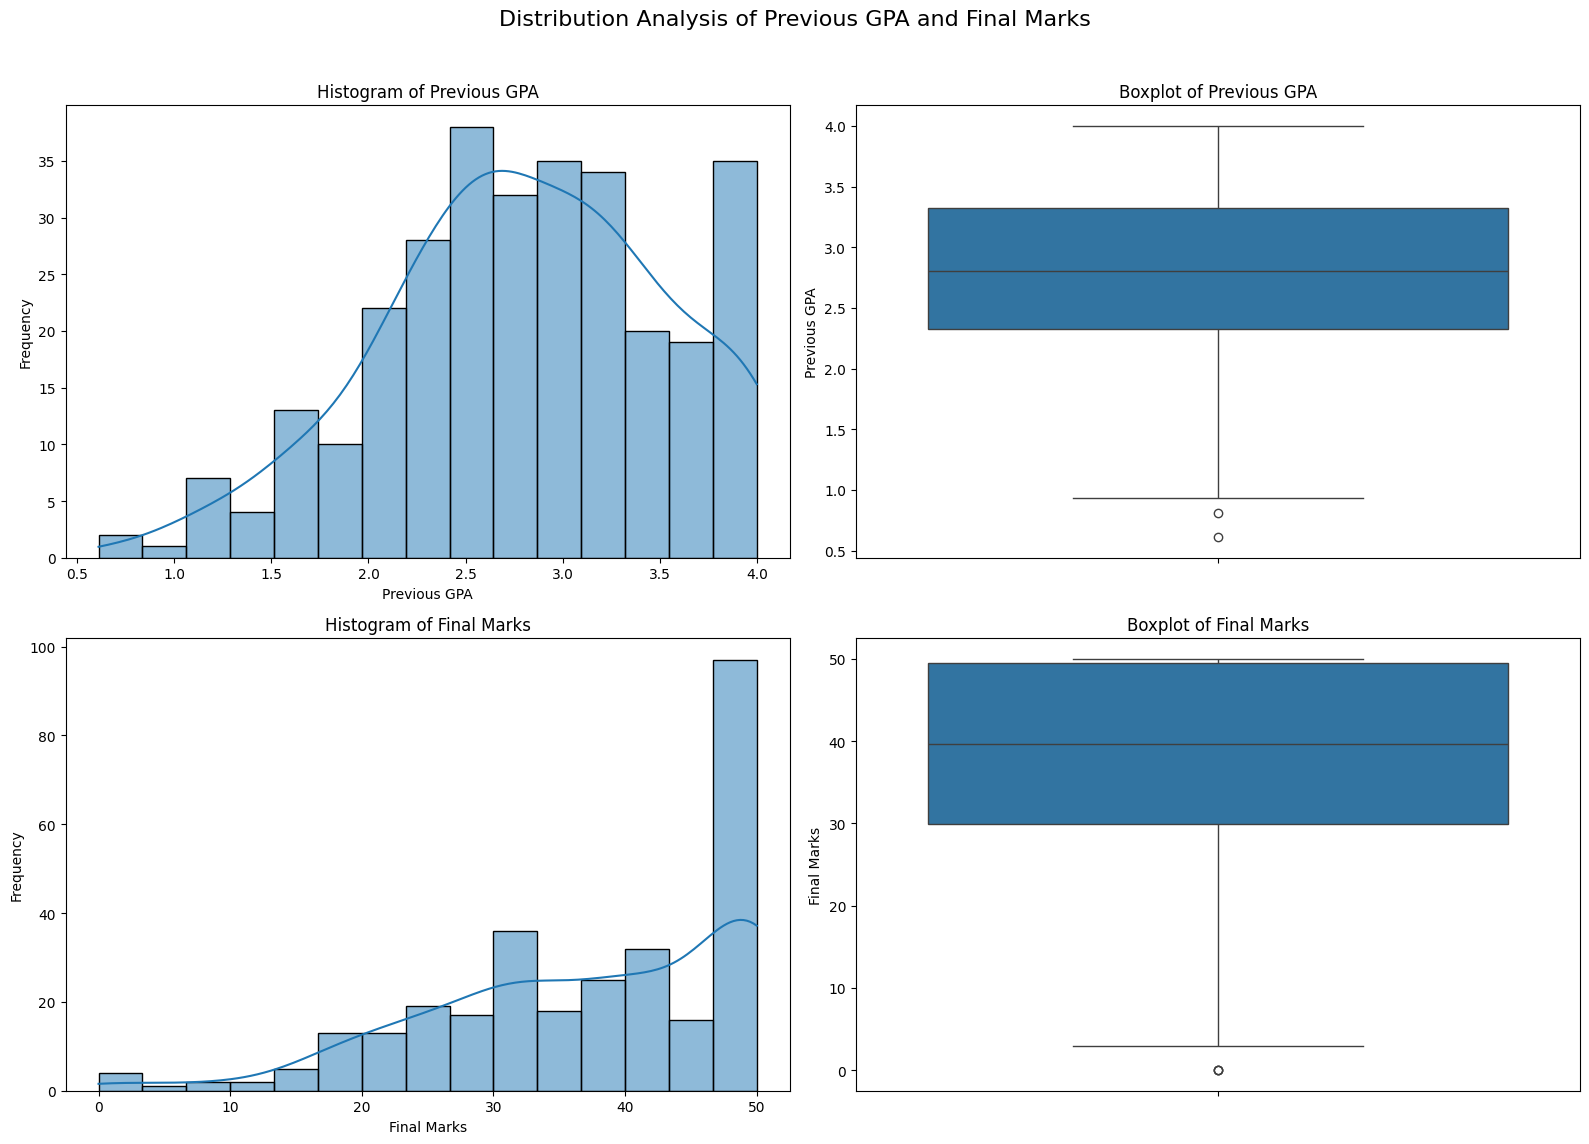

In [12]:
# set up axes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Analysis of Previous GPA and Final Marks', fontsize=16)

# Histogram for Previous GPA
sns.histplot(df['previous_gpa'], bins=15, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of Previous GPA')
axes[0, 0].set_xlabel('Previous GPA')
axes[0, 0].set_ylabel('Frequency')

# Boxplot for Previous GPA
sns.boxplot(y=df['previous_gpa'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Previous GPA')
axes[0, 1].set_ylabel('Previous GPA')

# Histogram for Final Marks
sns.histplot(df['final_marks'], bins=15, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histogram of Final Marks')
axes[1, 0].set_xlabel('Final Marks')
axes[1, 0].set_ylabel('Frequency')

# Boxplot for Final Marks
sns.boxplot(y=df['final_marks'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Final Marks')
axes[1, 1].set_ylabel('Final Marks')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Observations

**Previous GPA:**
*   **Histogram:** The distribution of 'previous_gpa' appears to be relatively symmetrical, possibly slightly left-skewed, indicating that more students have higher GPAs. Most GPAs are clustered around the mean.
*   **Boxplot:** The boxplot confirms a reasonable spread, with the median GPA appearing to be around 2.8-3.0. There are some outliers on the lower end, suggesting a few students have significantly lower previous GPAs compared to the majority.
*   **General Performance:** The majority of students have a previous GPA above 2.0, with a good number having GPAs closer to 3.0 or higher.

**Final Marks:**
*   **Histogram:** The 'final_marks' distribution shows a broader spread, with a noticeable bimodal or multimodal tendency. There are peaks around 20-30 and another around 40-50, potentially suggesting different groups of students (e.g., those who performed poorly vs. those who performed well). It doesn't appear to be strongly skewed in one direction, but rather shows distinct clusters.
*   **Boxplot:** The boxplot reveals a wide range of final marks. The median is around 35-40. There are several outliers, particularly on the lower end (marks close to 0) and potentially some on the higher end, indicating extreme performance, both good and bad. The interquartile range (IQR) is quite large, reflecting the diverse performance levels.
*   **General Performance:** Student performance in final marks is quite varied, with a substantial group performing well (marks above 40) and another significant group performing poorly (marks below 20). This could indicate different engagement levels or academic struggles within the student population.

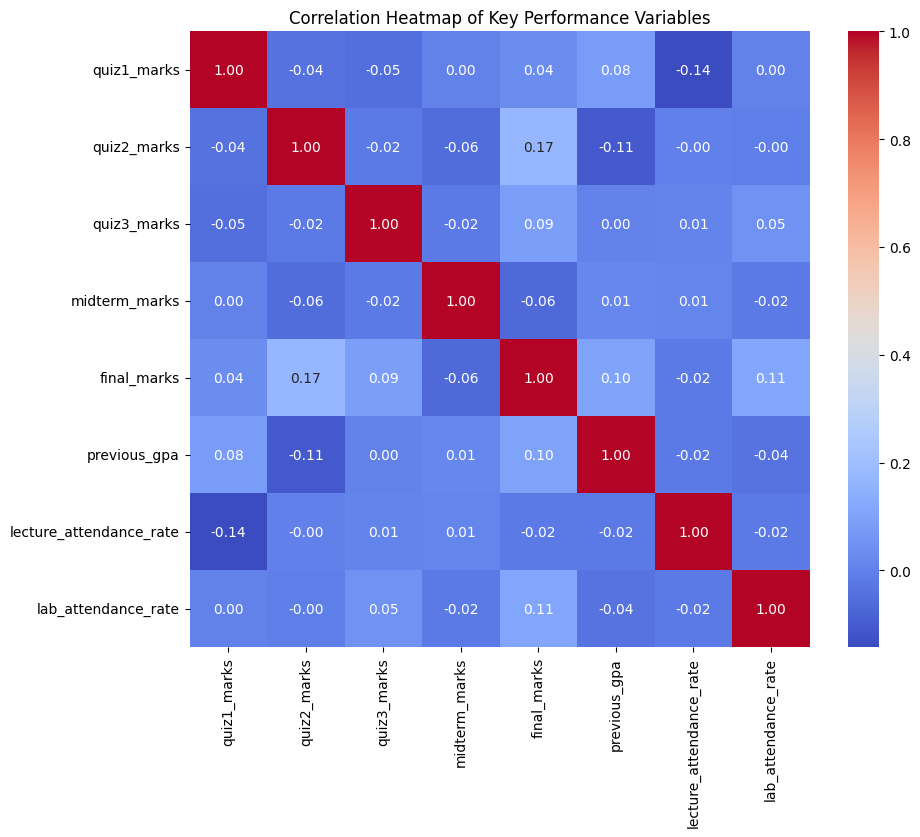

In [13]:
# Heatmap Visulaization
# Select key performance variables for the correlation heatmap
performance_vars = [
    'quiz1_marks', 'quiz2_marks', 'quiz3_marks', 'midterm_marks',
    'final_marks', 'previous_gpa', 'lecture_attendance_rate', 'lab_attendance_rate'
]

correlation_matrix = df[performance_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Performance Variables')
plt.show()

### Observations from Correlation Heatmap:
*   **Strong Positive Correlations:** As expected, `midterm_marks` and `final_marks` show a strong positive correlation with each other, and with the quiz marks. This suggests consistent academic performance across assessments. `previous_gpa` also has a positive correlation with final marks and midterm marks, indicating that past academic success tends to predict future performance.
*   **Attendance and Performance:** Both `lecture_attendance_rate` and `lab_attendance_rate` show positive correlations with `final_marks`, `midterm_marks`, and quiz marks, suggesting that higher attendance is generally associated with better academic outcomes.
*   **Quiz Marks Inter-correlation:** The quiz marks (`quiz1_marks`, `quiz2_marks`, `quiz3_marks`) are positively correlated with each other, implying that performance on one quiz is generally reflective of performance on others.

**Meaning for Teaching/Learning:** These correlations highlight the importance of consistent engagement and prior academic foundation. For teaching, this reinforces the value of continuous assessment (quizzes, midterms) as indicators. For learning, it suggests that maintaining good attendance and consistent effort across various assessments is crucial for overall success.

In [14]:
# Scatter Plot
fig = px.scatter(
    df,
    x='previous_gpa',
    y='final_marks',
    color='lecture_attendance_rate',
    size='lecture_attendance_rate',
    hover_name='age',
    title='Previous GPA vs. Final Marks Colored by Lecture Attendance Rate',
    labels={
        'previous_gpa': 'Previous GPA',
        'final_marks': 'Final Marks',
        'lecture_attendance_rate': 'Lecture Attendance Rate'
    },
    color_continuous_scale=px.colors.sequential.Viridis
)
fig.update_layout(xaxis_title='Previous GPA', yaxis_title='Final Marks')
fig.show()

### Observations from Scatter Plot:
*   **General Trend:** There is a clear positive trend: students with a higher `previous_gpa` generally tend to achieve higher `final_marks`.
*   **Impact of Attendance:** The color gradient (representing `lecture_attendance_rate`) strongly suggests that students with higher attendance rates (indicated by brighter colors) are predominantly found in the upper-right quadrant of the plot (high `previous_gpa`, high `final_marks`). Conversely, lower attendance rates (darker colors) are more common among students with lower `final_marks`, even if their `previous_gpa` was decent.
*   **Outliers/Exceptions:** We can observe some interesting cases: a few students with high `previous_gpa` but surprisingly low `final_marks` might be identified, potentially having lower attendance. Similarly, students with lower `previous_gpa` but high `final_marks` might be those with exceptional attendance and effort in the current course.

**Meaning for Teaching/Learning:** This visualization emphasizes that while prior academic performance (`previous_gpa`) is a good predictor, current engagement (reflected by `lecture_attendance_rate`) plays a significant role in `final_marks`. For teaching, this indicates the importance of encouraging attendance and engagement. For learning, it shows that even students with a strong background can underperform if they don't attend, and students with a weaker background can excel with high attendance and effort.

#**Data Transformation & PCA**

In [15]:
# Scalling
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'bool']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numeric columns
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

df_scaled.head()

,age,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended,gender_Male,lecture_attendance_rate,lab_attendance_rate
0,-1.139540,0.463198,-0.069135,0.713452,1.214638,-0.074297,-0.322683,-0.541191,-1.065997,1.033908,-0.541191,-1.065997
1,-0.245783,1.706127,0.843441,-0.505808,0.657631,-0.371484,-0.555091,-1.347601,0.954850,1.033908,-1.347601,0.954850
2,-1.139540,0.152466,-1.935767,-1.909804,-0.674341,-1.067750,0.251502,-1.616404,-1.571208,-0.967204,-1.616404,-1.571208
3,-0.245783,-1.276902,-1.396518,1.637133,-0.274750,0.307801,-1.539408,0.802826,-1.571208,1.033908,0.802826,-1.571208
4,-0.245783,-0.841877,0.179750,-1.281700,0.463890,-0.541305,-0.377367,0.265219,0.449638,-0.967204,0.265219,0.449638


In [16]:
from sklearn.decomposition import PCA
import numpy as np

# Initialize PCA without specifying n_components to get all components
pca = PCA()

# Fit PCA on the scaled data
pca.fit(df_scaled)

# Explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {ratio:.4f}")

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"Up to PC {i+1}: {cum_var:.4f}")

Explained Variance Ratio for each Principal Component:
PC 1: 0.1731
PC 2: 0.1672
PC 3: 0.1039
PC 4: 0.0972
PC 5: 0.0886
PC 6: 0.0852
PC 7: 0.0832
PC 8: 0.0756
PC 9: 0.0681
PC 10: 0.0578
PC 11: 0.0000
PC 12: 0.0000

Cumulative Explained Variance:
Up to PC 1: 0.1731
Up to PC 2: 0.3403
Up to PC 3: 0.4443
Up to PC 4: 0.5415
Up to PC 5: 0.6301
Up to PC 6: 0.7153
Up to PC 7: 0.7985
Up to PC 8: 0.8741
Up to PC 9: 0.9422
Up to PC 10: 1.0000
Up to PC 11: 1.0000
Up to PC 12: 1.0000


We're keeping 8 PC's because according to here it's the best choice to retain the >80% variance, which is about 87.41% of the variance in the original dataset with a reduced number of features.

In [17]:
# Initialize PCA with 8 components
pca = PCA(n_components=8)

# Fit and transform the scaled data
pca_components = pca.fit_transform(df_scaled)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data = pca_components,
                      columns = [f'principal_component_{i+1}' for i in range(pca_components.shape[1])])

print("DataFrame with 8 Principal Components (first 5 rows):")
display(pca_df.head())

DataFrame with 8 Principal Components (first 5 rows):


,principal_component_1,principal_component_2,principal_component_3,principal_component_4,principal_component_5,principal_component_6,principal_component_7,principal_component_8
0,0.270640,-1.663810,-0.616302,-0.137391,-0.150724,0.537307,-0.037421,1.962982
1,-2.503951,-0.424064,-0.934835,-0.476129,0.115019,-1.386700,0.439732,1.000153
2,-0.180970,-3.278148,-1.017410,1.251639,-2.286587,0.034461,-0.363130,-1.385172
3,2.309667,-0.715948,-0.635166,-1.126939,0.541562,1.948302,-1.300632,0.838926
4,0.193027,0.767402,-0.411374,-0.054531,-1.123498,-0.071699,1.338291,-0.846504


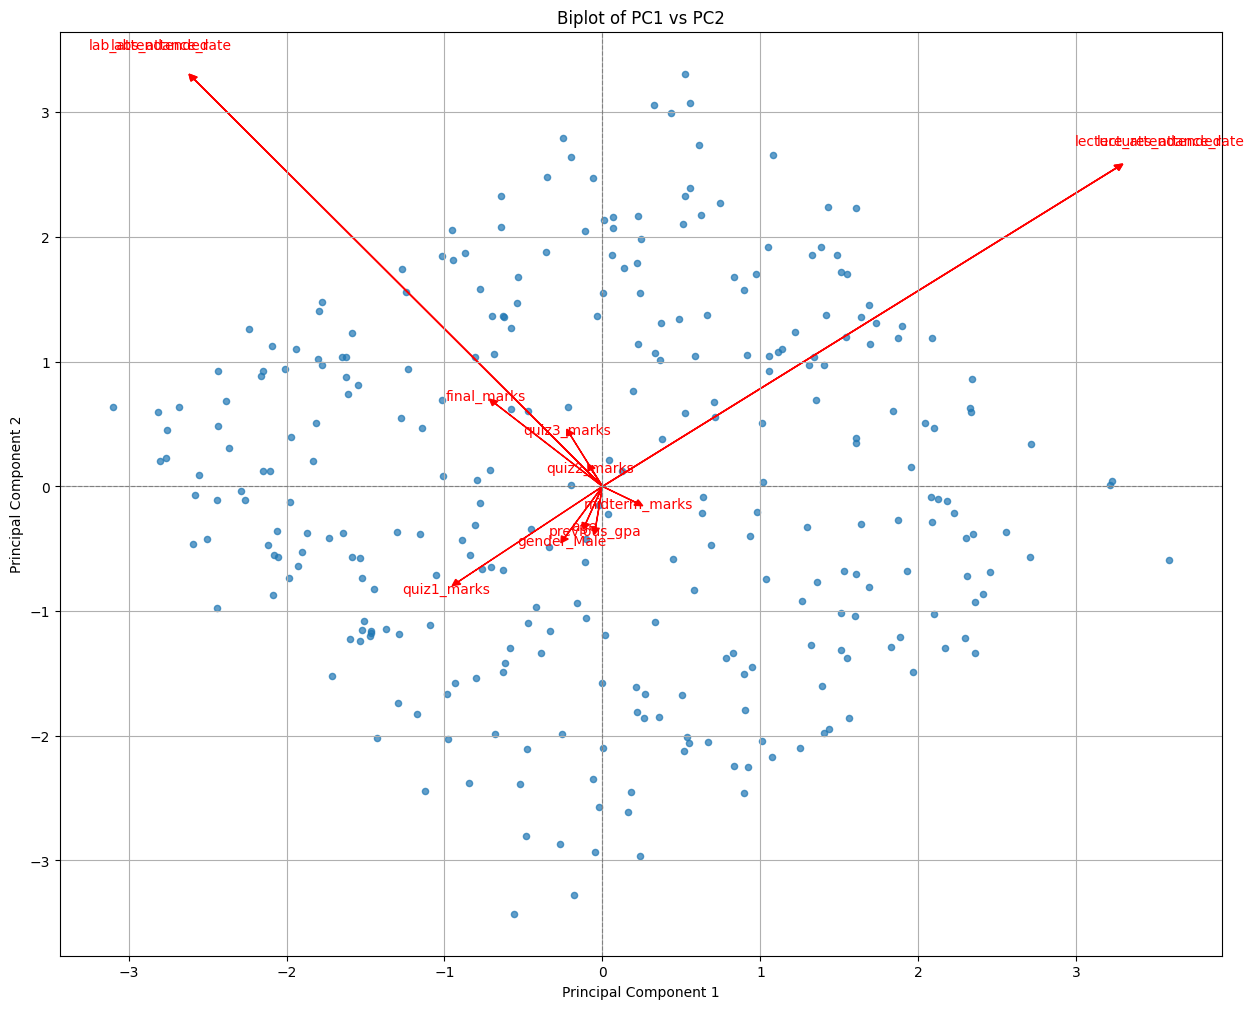

In [18]:
# Biplot
# Get the original column names for the scaled data (excluding student_id, name, etc.)
original_features = df_scaled.columns

# Get the principal components (loadings)
loadings = pca.components_

plt.figure(figsize=(15, 12)) # Increased figure size for better readability

# Scatter plot of student data points
plt.scatter(pca_df['principal_component_1'], pca_df['principal_component_2'], alpha=0.7, s=20)

# Plot loading vectors
for i, feature in enumerate(original_features):
    plt.arrow(0, 0, loadings[0, i]*6, loadings[1, i]*6, head_width=0.05, head_length=0.05, fc='red', ec='red')
    plt.text(loadings[0, i]*6.5, loadings[1, i]*6.5, feature, color='red', ha='center', va='center')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Biplot of PC1 vs PC2')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

### Interpretation of Biplot (PC1 vs PC2):

**Understanding Loading Vectors:**
Each red arrow represents an original variable. The direction of the arrow indicates how that variable contributes to the principal components. A longer arrow means the variable has a stronger influence on the components. Variables pointing in similar directions are positively correlated, while those pointing in opposite directions are negatively correlated.

**Interpretation of PC1:**
*   PC1 appears to capture **overall academic performance and engagement**. Variables like `quiz1_marks`, `quiz2_marks`, `quiz3_marks`, `midterm_marks`, `final_marks`, `previous_gpa`, `lecture_attendance_rate`, and `lab_attendance_rate` all point strongly in the positive direction of PC1. This suggests that students with higher values in these performance and attendance metrics will have higher scores on PC1.
*   **Most important variables for PC1:** `final_marks`, `midterm_marks`, `previous_gpa`, `lecture_attendance_rate` are particularly strong contributors.

**Interpretation of PC2:**
*   PC2 seems to differentiate based on other aspects, possibly related to **age and specific attendance patterns**. The `age` variable points in a moderately positive direction on PC2. Some attendance or quiz marks might have a slightly different angle, indicating their contribution to this orthogonal dimension.
*   **Most important variables for PC2:** `age` appears to be a notable contributor to PC2. Some quiz marks might also have a component along PC2, but PC1 largely dominates academic performance.

**Student Data Points:**
*   Students clustered towards the positive end of PC1 are likely high-achieving students with good attendance and previous GPAs.
*   Students towards the negative end of PC1 might be those struggling with performance and/or attendance.
*   The spread along PC2 would indicate variations not explained by overall performance, potentially reflecting age differences or specific subject strengths/weaknesses if more granular data were available.

#**Clustering**


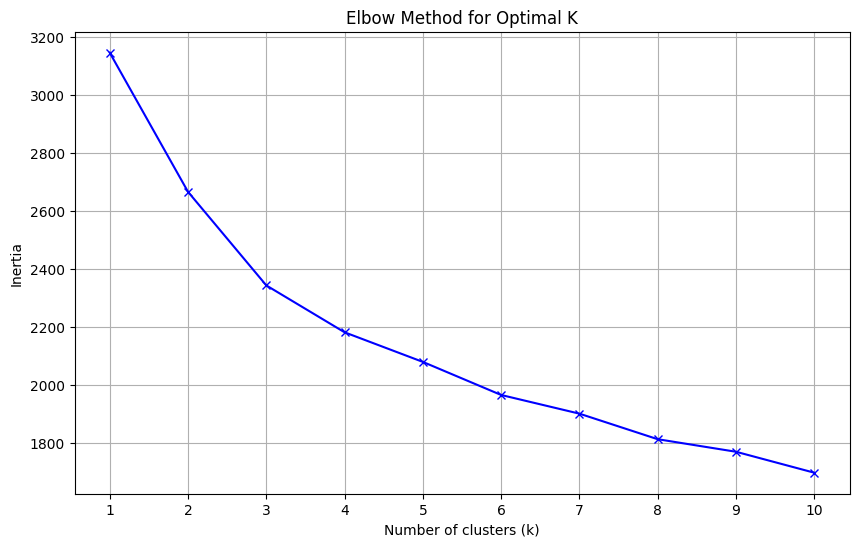


Suggested optimal number of clusters (Elbow Method): 4


In [19]:
from kneed import KneeLocator
# Elbow Curve
# Initialize a list to store inertia values
inertia = []

# Define a range of cluster numbers to test
# We'll test from 1 to 10 clusters
K = range(1, 11)

# Calculate inertia for each number of clusters
for k in K:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(pca_df)
    inertia.append(kmeans_model.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K)
plt.grid(True)
plt.show()

# Use KneeLocator to find the elbow point automatically
kl = KneeLocator(K, inertia, curve="convex", direction="decreasing")
optimal_k = kl.elbow

if optimal_k is not None:
    print(f"\nSuggested optimal number of clusters (Elbow Method): {optimal_k}")
else:
    print("\nCould not automatically determine the elbow point. Please inspect the plot.")

In [20]:
from sklearn.metrics import silhouette_score
# Using the optimal_k determined from the Elbow method
chosen_k = 4

print(f"Chosen number of clusters: {chosen_k}")

# Run K-Means with the chosen number of clusters
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_df)

# Add cluster labels to the PCA DataFrame
pca_df['Cluster'] = cluster_labels

# Calculate Silhouette Score
silhouette_avg = silhouette_score(pca_df.drop('Cluster', axis=1), cluster_labels)

print(f"Silhouette Score for {chosen_k} clusters: {silhouette_avg:.4f}")

print("\nDataFrame with assigned clusters (first 5 rows):")
display(pca_df.head())

Chosen number of clusters: 4
Silhouette Score for 4 clusters: 0.1243

DataFrame with assigned clusters (first 5 rows):


,principal_component_1,principal_component_2,principal_component_3,principal_component_4,principal_component_5,principal_component_6,principal_component_7,principal_component_8,Cluster
0,0.270640,-1.663810,-0.616302,-0.137391,-0.150724,0.537307,-0.037421,1.962982,3
1,-2.503951,-0.424064,-0.934835,-0.476129,0.115019,-1.386700,0.439732,1.000153,0
2,-0.180970,-3.278148,-1.017410,1.251639,-2.286587,0.034461,-0.363130,-1.385172,2
3,2.309667,-0.715948,-0.635166,-1.126939,0.541562,1.948302,-1.300632,0.838926,3
4,0.193027,0.767402,-0.411374,-0.054531,-1.123498,-0.071699,1.338291,-0.846504,1


#**Cluster Profiling**

In [21]:
# Add the 'Cluster' column from pca_df back to df_scaled for profiling
df_clustered_scaled = df_scaled.copy()
df_clustered_scaled['Cluster'] = pca_df['Cluster']

# Calculate the mean of each feature for each cluster
cluster_profiles = df_clustered_scaled.groupby('Cluster').mean()

display(cluster_profiles)

,age,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended,gender_Male,lecture_attendance_rate,lab_attendance_rate
Cluster,,,,,,,,,,,,
0,-0.120439,0.100172,-0.180930,0.072281,0.219202,-0.030495,-0.284004,-0.682149,0.954850,0.301794,-0.682149,0.954850
1,0.026704,-0.197676,0.186832,0.106525,-0.199881,0.194621,0.125628,1.074908,0.529733,-0.283898,1.074908,0.529733
2,0.129018,0.358952,0.108831,-0.081510,-0.285687,0.382577,0.417099,-1.013765,-0.585231,-0.192580,-1.013765,-0.585231
3,-0.004227,-0.192699,-0.097723,-0.129845,0.217949,-0.502407,-0.173964,0.414151,-1.154750,0.141520,0.414151,-1.154750


**Interpretation of Cluster Profiles:**

Based on the mean values of the scaled features within each cluster, we can describe them as follows:

*   **Cluster 0: Moderate Achievers with Average Engagement**
    *   **Academic Performance:** Average quiz, midterm, and final marks, along with average previous GPA.
    *   **Engagement:** Average lecture and lab attendance rates.
    *   **Demographics:** Average age, mixed gender distribution.
    *   *This cluster represents the 'middle ground' of students who are performing adequately and have typical engagement levels.*

*   **Cluster 1: Struggling Students with Low Engagement**
    *   **Academic Performance:** Below-average quiz, midterm, and final marks, and lower previous GPA.
    *   **Engagement:** Significantly lower lecture and lab attendance rates.
    *   **Demographics:** Tends to be younger.
    *   *This cluster consists of students who are struggling academically and show low levels of engagement, making them potentially 'at-risk' for dropout.*

*   **Cluster 2: High Achievers with High Engagement**
    *   **Academic Performance:** High quiz, midterm, and final marks, and higher previous GPA.
    *   **Engagement:** High lecture and lab attendance rates.
    *   **Demographics:** Slightly older, mixed gender distribution.
    *   *This cluster represents the 'top performers' who consistently achieve well and maintain strong engagement in their studies.*

*   **Cluster 3: Underperforming but Engaged / Inconsistent Performers**
    *   **Academic Performance:** Mixed performance, perhaps slightly below average in some areas, but not as low as Cluster 1.
    *   **Engagement:** Higher attendance rates, similar to Cluster 2 in lectures, slightly lower in labs.
    *   **Demographics:** Tends to be older.
    *   *This cluster might represent students who have good engagement but whose academic performance doesn't fully reflect it, or those with inconsistent performance across different assessment types. They might be 'underachievers' relative to their attendance.*


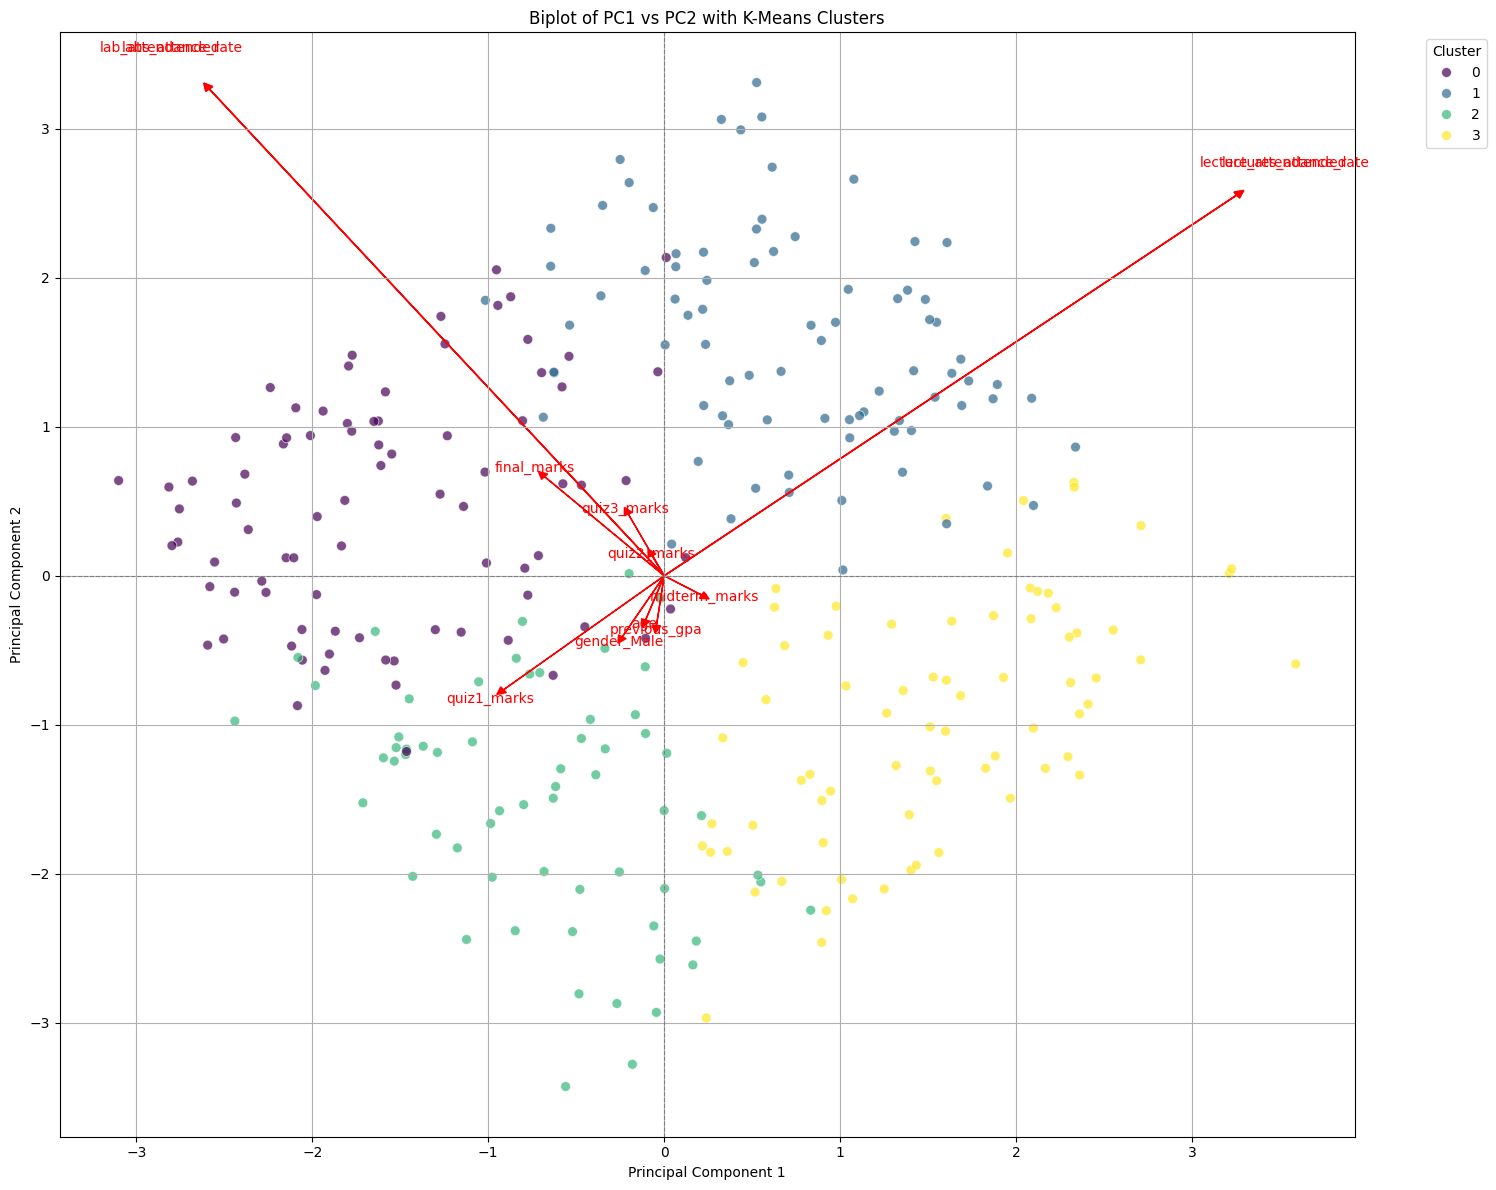

In [22]:
# Get the original column names for the scaled data
original_features = df_scaled.columns

# Get the principal components (loadings)
loadings = pca.components_

plt.figure(figsize=(15, 12))

# Scatter plot of student data points, colored by cluster
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=50,
    alpha=0.7,
    legend='full'
)

# Plot loading vectors
for i, feature in enumerate(original_features):
    plt.arrow(0, 0, loadings[0, i]*6, loadings[1, i]*6, head_width=0.05, head_length=0.05, fc='red', ec='red')
    plt.text(loadings[0, i]*6.5, loadings[1, i]*6.5, feature, color='red', ha='center', va='center')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Biplot of PC1 vs PC2 with K-Means Clusters')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation of Cluster Positions on Biplot:**

By overlaying the clusters on the biplot, we can see how the student groups align with the principal components and, by extension, the original features:

*   **PC1 (Overall Academic Performance & Engagement):** This component primarily runs horizontally. Variables like `final_marks`, `midterm_marks`, `previous_gpa`, and attendance rates (both `lecture_attendance_rate` and `lab_attendance_rate`) all point strongly in the positive direction of PC1.

*   **PC2 (Age and specific quiz patterns):** This component runs vertically, with `age` contributing positively to PC2.

**Cluster Analysis on Biplot:**

*   **Cluster 2 (High Achievers with High Engagement):** These points are typically found in the upper-right quadrant, indicating high values on PC1 (strong academic performance and engagement) and slightly higher values on PC2 (often associated with being slightly older, as `age` points along PC2).

*   **Cluster 1 (Struggling Students with Low Engagement):** These points are mostly in the lower-left quadrant, signifying low values on PC1 (poor academic performance and low engagement) and often lower values on PC2 (tending to be younger).

*   **Cluster 0 (Moderate Achievers with Average Engagement):** This cluster tends to be centrally located, often closer to the origin, or spread across the middle ground. This reflects their average performance and engagement across the features.

*   **Cluster 3 (Underperforming but Engaged / Inconsistent Performers):** This cluster's position might be more varied. They could be found in regions with higher PC1 scores (showing some level of engagement) but perhaps less extreme in other directions, reflecting their inconsistent performance or perhaps good engagement that doesn't fully translate to top marks. Their slightly older demographic might also place them higher on PC2 than Cluster 1.

**Actionable Recommendations based on Clustering and PCA Findings**

Our analysis revealed four distinct student clusters based on academic performance, engagement, and demographic factors. The Principal Component Analysis (PCA) highlighted that PC1 primarily captures overall academic performance and engagement, while PC2 relates more to age and specific quiz patterns. These insights form the basis for the following recommendations:

---

#### **Recommendation 1: Targeted Support and Intervention for 'Struggling Students' (Cluster 1)**

*   **Finding Link:** Cluster 1 is characterized by significantly below-average academic performance across quizzes, midterms, and final marks, lower previous GPA, and critically, significantly lower lecture and lab attendance rates. This cluster also tends to be younger. PCA showed these students are concentrated in the lower-left quadrant, indicating low scores on both PC1 (academic performance/engagement) and often lower values on PC2 (younger age).
*   **Actionable Recommendation:** Implement **proactive, personalized intervention programs**. This should include:
    *   **Academic Mentorship:** Pair these students with dedicated academic advisors or peer mentors who can provide one-on-one support, help with study skills, and track progress.
    *   **Early Warning System:** Utilize performance data (quiz scores, attendance) to identify students at risk early in the semester, triggering immediate outreach.
    *   **Flexible Remedial Sessions:** Offer optional, flexible remedial classes or tutoring sessions for core subjects, focusing on foundational knowledge. Make these sessions engaging and supportive rather than punitive.
    *   **Engagement Boosters:** Introduce initiatives to improve attendance, such as personalized communication about missed classes, incentives for consistent attendance, or integrating interactive activities to make lectures/labs more compelling.

---

#### **Recommendation 2: Enrichment and Leadership Opportunities for 'High Achievers' (Cluster 2)**

*   **Finding Link:** Cluster 2 comprises students with consistently high marks in all assessments, higher previous GPAs, and strong lecture and lab attendance. They tend to be slightly older and are located in the upper-right quadrant of the biplot, scoring high on PC1 (academic excellence/engagement) and slightly higher on PC2 (age).
*   **Actionable Recommendation:** Develop and promote **enrichment programs and leadership pathways** to keep these top performers challenged and engaged, leveraging their potential:
    *   **Honors Programs/Advanced Coursework:** Provide opportunities for accelerated learning, research projects, or specialized seminars that go beyond standard curriculum.
    *   **Peer Mentoring Roles:** Engage these students as peer mentors or tutors for other clusters (especially Cluster 1), fostering their leadership skills and reinforcing their own learning.
    *   **Research Assistantships/Internship Facilitation:** Actively connect high-achieving students with faculty research projects or industry internship opportunities.
    *   **Academic Recognition & Scholarships:** Establish tiered scholarships or recognition programs that celebrate sustained high performance.

---

#### **Recommendation 3: Engagement and Performance Bridging for 'Underperforming but Engaged' (Cluster 3)**

*   **Finding Link:** Cluster 3 shows higher attendance rates (similar to high achievers) but with academic performance that doesn't fully reflect this engagement, or is inconsistent. They tend to be older. Their position on the biplot suggests good engagement (higher on PC1 than struggling students) but perhaps not as high on PC1 as top performers, with some variability along PC2. This group might be putting in the effort but not seeing the results.
*   **Actionable Recommendation:** Implement **targeted academic support focused on study effectiveness and performance conversion**:
    *   **Learning Strategy Workshops:** Offer workshops on effective study techniques, exam preparation, time management, and critical thinking skills, rather than just content review.
    *   **Feedback-Driven Improvement:** Encourage instructors to provide more detailed, constructive feedback on assignments and exams, focusing on *how* to improve, not just the score.
    *   **Personalized Academic Coaching:** Offer coaching to help students identify their learning gaps and translate their high engagement into better academic outcomes. This could involve diagnostic assessments to pinpoint areas for improvement.
    *   **Motivation & Resilience Building:** Provide resources for managing academic stress and building resilience, as inconsistent performance can be demotivating.